# Recourse

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.analysis.plotting import (
    plot_model_agreement_multiple_tasks,
    plot_model_agreement_barplot,
)
from monoculture.baseline.utils import load_baselines

In [ ]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = [
    "ACSIncome",
    "ACSEmployment",
    "BRFSS_Blood_Pressure",
]  # ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

data = None

tasks ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']


## Load Baselines

In [11]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)
baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}  ## why 0.5?
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for BRFSS_Blood_Pressure.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Blood_Pressure'.
Skipping LR
Skipping GBM
Skipping XGBoost


,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


## Load Task Data

In [7]:
data = load_task_data(TASKS, Path("./data"))
data.keys()

dict_keys(['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure'])

## Load predictions

In [105]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [106]:
print(df_same_prompt.shape)
assert set(TASKS).issubset(
    set(df_same_prompt["task"].unique())
), "Results for all tasks to be analysed have to be available."

(288, 14)


In [107]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50918/668434544.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50918/668434544.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50918/668434544.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

## Restrict analysis to models based on performance or true labels?

In [ ]:
restrict_to_better_const = True
restrict_to_model_family = False  #'Llama'  # name of family
restrict_to_base_models = True
restrict_to_it_models = False
assert not (restrict_to_base_models & restrict_to_it_models), "Choose one or none."
restrict_to_topk = False  # 10 # NOT IMPLEMENTED YET

predictions = predictions_all.copy()


if any([restrict_to_better_const]):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        print(task, predictions[task].shape)

if restrict_to_model_family:
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (restrict_to_model_family in row.model),
                    axis=1,
                )
            ]["model"].unique()
        )
        print(len(models_filtered))
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)


if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

ACSIncome (166450, 40)
ACSEmployment (323611, 42)
BRFSS_Blood_Pressure (84676, 36)
ACSIncome (166450, 18)
ACSEmployment (323611, 22)
BRFSS_Blood_Pressure (84676, 16)


## Recourse: Plot Impact of Agreement for Individual

In [169]:
tp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

fn_rates = {
    task: df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

neg_pred_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["ppr"]
    for task in TASKS
}

pos_pred_rates = {
    task: df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["ppr"]
    for task in TASKS
}

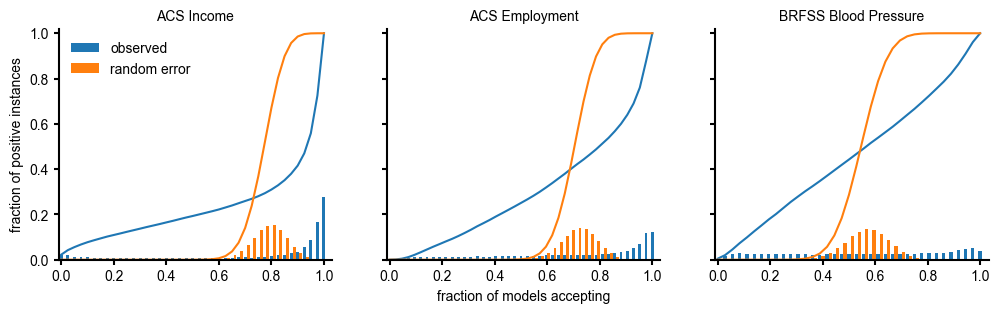

In [ ]:
tasks_to_plot = TASKS
restrict_only_pos_instances = True

file_name = "".join(
    [
        f"{num_shots}-shot-recourse",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        f"_{restrict_to_model_family}" if restrict_to_model_family else "",
        "_better_const" if restrict_to_better_const else "",
        "_base_models" if restrict_to_base_models else "",
        "_it_models" if restrict_to_it_models else "",
        "_pos_instances" if restrict_only_pos_instances else "",
        # "_neg_instances" if restrict_to_negative_label else "",
        ".png",
    ]
)

plot_model_agreement_multiple_tasks(
    tasks=tasks_to_plot,
    figsize=(12, 3),
    predictions=predictions,
    baseline_rates=tp_rates,
    data=data,
    restrict_only_pos_instances=True,
    title="",  # "Model agreement on positive instances",
    plot_cumulative=True,
    save_path=FIGURES_ROOT_DIR / "paper" / file_name,
    # indicate_mean=False,
    count_accepted=True,
    # xlabel="fraction of models rejecting"
)

## Predicted vs Expected Fraction of Models Accepting an Individual (≈Calibration Plot)

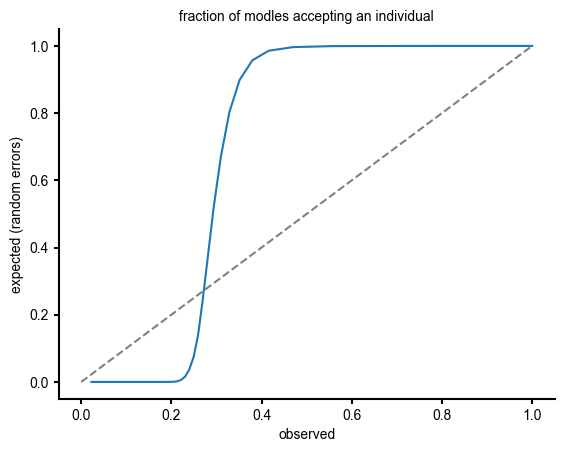

In [ ]:
from monoculture.analysis.plotting import get_observed_acceptance_df
import scipy as sp

num_models, frqs = get_observed_acceptance_df(
    predictions["ACSIncome"],
    restrict_only_pos_instances=True,
    true_labels=data["ACSIncome"][1],
    padding=True,
)
frqs = frqs / frqs.sum()

prob_expected = torch.tensor(
    [
        sp.stats.poisson_binom.pmf(
            k=num_accept,
            p=tp_rates["ACSIncome"].values,
        )
        for num_accept in range(max(num_models) + 1)
    ]
)

plt.plot(np.cumsum(frqs.numpy()), np.cumsum(prob_expected.numpy()))
plt.plot([0, 1], [0, 1], color="grey", linestyle="dashed")
plt.xlabel("observed")
plt.ylabel("expected (random errors)")
plt.title("fraction of modles accepting an individual")
plt.show()

## Next

## Systemic Failure (No Recourse) as a function of the model set size

In [ ]:
topk = 10

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i, task in enumerate(TASKS[:2] + TASKS[-1:]):
    M = topk  # len(models_above_baseline[task])
    obs_mean = {
        s: np.array(observed_no_recourse[task][s]).mean() for s in range(1, M + 1)
    }
    exp_mean = {
        s: np.array(expected_no_recourse[task][s]).mean() for s in range(1, M + 1)
    }
    obs_std = {
        s: np.array(observed_no_recourse[task][s]).std() for s in range(1, M + 1)
    }
    exp_std = {
        s: np.array(expected_no_recourse[task][s]).std() for s in range(1, M + 1)
    }  # var()/s  standard error
    axs[i].set_ylim(-0.01, 0.5)

    axs[i].set_title(task.replace("ACS", "ACS ").replace("_", " "))
    axs[i].plot(
        np.arange(1, M + 1),
        [exp_mean[s] for s in range(1, M + 1)],
        color="C1",
        label="random error",
    )  # expected based on model FNR
    axs[i].plot(
        np.arange(1, M + 1),
        [obs_mean[s] for s in range(1, M + 1)],
        color="C0",
        label="observed",
    )
    axs[i].fill_between(
        np.arange(1, M + 1),
        [exp_mean[s] + exp_std[s] for s in range(1, M + 1)],
        [exp_mean[s] - exp_std[s] for s in range(1, M + 1)],
        alpha=0.2,
        color="C1",
    )
    axs[i].fill_between(
        np.arange(1, M + 1),
        [obs_mean[s] + obs_std[s] for s in range(1, M + 1)],
        [obs_mean[s] - obs_std[s] for s in range(1, M + 1)],
        alpha=0.2,
        color="C0",
    )

    axs[i].set_xticks(np.arange(1, M + 1))

axs[1].set_xlabel("size of the model set")
axs[0].set_ylabel("fraction of individuals\n experiencing no recourse")
axs[0].legend()

# plt.savefig(
#     "/Users/mgorecki/Documents/2025-04-SAB-meeting/figures/no_recourse.png",
# )

plt.show()